### Imports

In [1]:
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import Dataset
from transformers import (BertTokenizer, BertForMultipleChoice,Trainer, TrainingArguments)

import matplotlib.pyplot as plt

### Load & Inspect Dataset

In [2]:
df = pd.read_csv("QA Dataset.csv")

df = df.dropna(how="all") #Remove na values
df["ans"] = df["ans"].astype(int) #Converts the correct answer column into integers

print(df.head())
print(df.shape)
print(df["ans"].value_counts().sort_index())

                                            question  \
0  Meta se ssir l-elezzjoni bikrija mħabbra min R...   
1  Lil min informa Robert Abela dwar ix-xogħljiet...   
2  X'kienet l-iskuża uffiċjali għas-sejħa ta' ele...   
3  Kemm kienet twila l-laqgħa bejn il-Prim Minist...   
4  Liema kumpanija żar il-Kap tal-PN b'rabta ma' ...   

                    option_0                              option_1  \
0       Fit-tletin ta' Mejju                    Fl-ewwel ta' Mejju   
1  Lill-Kap tal-Oppożizzjoni  Lill-President Miriam Spiteri Debono   
2     Kriżi ekonomika lokali                    Protesti fit-toroq   
3  Kienet laqgħa twila ħafna                  Kienet laqgħa qasira   
4     Kumpanija tat-trasport                     Fabbrika tal-ikel   

                      option_2                            option_3  ans  
0        Fil-ħmistax ta' Ġunju                  Fl-għaxra t' April    0  
1  Lill-Kummissjoni Elettorali             Lill-Ispeaker tal-Kamra    1  
2     Politika inter

### Create Varied Dataset

In [3]:
# For balanced datasets: 
# Groups the dataset by correct answer position
# From each answer group choose n examples
# Reset row numbering

df_balanced_28 = (
    df.groupby("ans", group_keys=False) 
      .apply(lambda x: x.sample(n=7, random_state=42)) 
      .reset_index(drop=True) 
)

df_balanced_48 = (
    df.groupby("ans", group_keys=False)
      .apply(lambda x: x.sample(n=12, random_state=42))
      .reset_index(drop=True)
)

df_balanced_full = df.copy().reset_index(drop=True)

# Create Imbalanced dataset:
df_imbalanced_50 = pd.concat([
    df[df["ans"] == 1].sample(n=25, replace=True, random_state=42), #Takes 25 examples where the correct answer is option 1
    df[df["ans"] != 1].sample(n=25, random_state=42) # Takes 25 examples where the answer is not option 1
]).sample(frac=1, random_state=42).reset_index(drop=True) # Combines them, shuffles them, and resets row numbers


# Printing general information
print("Balanced 28")
print(df_balanced_28["ans"].value_counts().sort_index())

print("\nBalanced 48")
print(df_balanced_48["ans"].value_counts().sort_index())

print("\nBalanced Full")
print(df_balanced_full["ans"].value_counts().sort_index())

print("\nImbalanced 50")
print(df_imbalanced_50["ans"].value_counts().sort_index())

Balanced 28
ans
0    7
1    7
2    7
3    7
Name: count, dtype: int64

Balanced 48
ans
0    12
1    12
2    12
3    12
Name: count, dtype: int64

Balanced Full
ans
0    21
1    19
2    21
3    21
Name: count, dtype: int64

Imbalanced 50
ans
0    10
1    25
2    10
3     5
Name: count, dtype: int64


C:\Users\sarah\AppData\Local\Temp\ipykernel_18404\2463876032.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=7, random_state=42))
C:\Users\sarah\AppData\Local\Temp\ipykernel_18404\2463876032.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=12, random_state=42))


### Choosing Dataset

In [4]:
# Change this line to test the other dataset configurations

experiment_df = df_balanced_28
#experiment_df = df_balanced_48
#experiment_df = df_balanced_full
#experiment_df = df_imbalanced_50

### Split Dataset

In [5]:
# Split dataset into training set and testing set (80/20)
train_df, test_df = train_test_split(
    experiment_df,
    test_size=0.2,
    random_state=42,      # Keeps results reproducible
    stratify=experiment_df["ans"]   # Preserves answer distribution
)

# Check how many examples are in each split
print("Training examples:", len(train_df))
print("Testing examples:", len(test_df))

# Check answer distribution in training data
print("\nTrain distribution:")
print(train_df["ans"].value_counts().sort_index())

# Check answer distribution in testing data
print("\nTest distribution:")
print(test_df["ans"].value_counts().sort_index())

Training examples: 22
Testing examples: 6

Train distribution:
ans
0    5
1    6
2    5
3    6
Name: count, dtype: int64

Test distribution:
ans
0    2
1    1
2    2
3    1
Name: count, dtype: int64


### Load Pre-trained BERT Model

In [6]:
# Load multilingual BERT model
model_name = "bert-base-multilingual-cased"

# Load tokenizer for converting text into tokens
tokenizer = BertTokenizer.from_pretrained(model_name)

# Load BERT model for multiple-choice question answering
model = BertForMultipleChoice.from_pretrained(model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForMultipleChoice LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Dataset Class

In [7]:
class MultipleChoiceDataset(Dataset): # tells PyTorch how to read CSV rows
    def __init__(self, dataframe, tokenizer):
        self.dataframe = dataframe.reset_index(drop=True) # Stores dataframe inside the class & do not keep old indexes
        self.tokenizer = tokenizer # store tokeniser

    def __len__(self):
        return len(self.dataframe) # Returns dataset size

    def __getitem__(self, idx): #Returns ONE training example
        row = self.dataframe.iloc[idx]
        question = row["question"] # extract question

        options = [ #extract options
            row["option_0"],
            row["option_1"],
            row["option_2"],
            row["option_3"]
        ]

        encoded = self.tokenizer( # convert text to numbers
            [question] * 4,
            options,
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt" # Convert everything into PyTorch tensors
        )

        encoded["labels"] = torch.tensor(int(row["ans"])) #Add correct answer
        return encoded

### Create PyTorch Datasets

In [8]:
train_dataset = MultipleChoiceDataset(train_df, tokenizer) #Converts training set into a PyTorch dataset
test_dataset = MultipleChoiceDataset(test_df, tokenizer) #Converts testing dataframe into a PyTorch dataset

### Training Configuration + Training

In [9]:
# Define Training Arguments
training_args = TrainingArguments(
    output_dir="./bert_maltese_mcq", #Creates a folder where the trained model gets saved
    num_train_epochs=3, #Determines how many times BERT reads the full training dataset
    per_device_train_batch_size=2, #Controls how many questions are processed at one time
    learning_rate=2e-5, #Controls how much the model changes after each mistake
    logging_steps=5 #Print training progress every 5 steps
)

### Accuracy Metric

In [10]:
#Creates evaluation function
def compute_metrics(pred):
    predictions = pred.predictions.argmax(-1) # gets model predictions and find highest value
    labels = pred.label_ids #Gets actual correct answers from dataset
    return {
        "accuracy": accuracy_score(labels, predictions)
    }

### Create Trainer + Train Model

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

C:\Users\sarah\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
5,1.372815
10,1.350041
15,1.382195
20,1.348252
25,1.305708
30,1.327547


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=33, training_loss=1.3514407475789387, metrics={'train_runtime': 377.5998, 'train_samples_per_second': 0.175, 'train_steps_per_second': 0.087, 'total_flos': 17365173737472.0, 'train_loss': 1.3514407475789387, 'epoch': 3.0})

### Model Evaluation

In [12]:
results = trainer.evaluate()
print(results)

C:\Users\sarah\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy
1.327547,1.407136,33,0.333333


{'eval_loss': 1.4071364402770996, 'eval_accuracy': 0.3333333333333333}


### Predict Function

In [13]:
def predict_mcq(question, options):
    # Convert text into tokens (numbers)
    inputs = tokenizer(
        [question] * 4,
        options,
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )

    # Add dimension -> BERT expects (1 question, 4 choices, 128 tokens each)
    inputs = {
        key: value.unsqueeze(0)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad(): # Disable gradients
        outputs = model(**inputs) # Send data through model

    predicted_index = torch.argmax(outputs.logits, dim=1).item() # Find highest score
    predicted_answer = options[predicted_index] # Get actual answer text

    return predicted_index, predicted_answer

### Full Accuracy Testing

In [14]:
correct = 0

for i in range(len(experiment_df)):

    predicted_index, predicted_answer = predict_mcq(
        experiment_df.loc[i, "question"],
        [
            experiment_df.loc[i, "option_0"],
            experiment_df.loc[i, "option_1"],
            experiment_df.loc[i, "option_2"],
            experiment_df.loc[i, "option_3"]
        ]
    )

    actual = int(experiment_df.loc[i, "ans"])

    if predicted_index == actual:
        correct += 1

full_accuracy = correct / len(experiment_df)

print("Full dataset accuracy:", full_accuracy)

Full dataset accuracy: 0.6785714285714286


### Classification Report & Confusion Matrix

              precision    recall  f1-score   support

     Class 0       0.56      0.71      0.62         7
     Class 1       0.71      0.71      0.71         7
     Class 2       1.00      0.71      0.83         7
     Class 3       0.57      0.57      0.57         7

    accuracy                           0.68        28
   macro avg       0.71      0.68      0.69        28
weighted avg       0.71      0.68      0.69        28



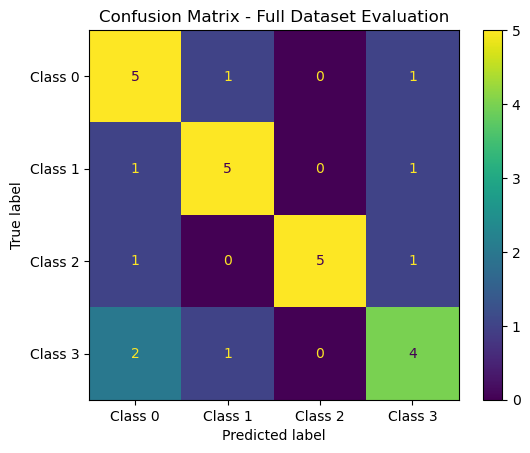

In [15]:
# Store true labels and predicted labels for evaluation
true_labels = []
predicted_labels = []

for i in range(len(experiment_df)):
    question = experiment_df.loc[i, "question"]
    options = [
        experiment_df.loc[i, "option_0"],
        experiment_df.loc[i, "option_1"],
        experiment_df.loc[i, "option_2"],
        experiment_df.loc[i, "option_3"]
    ]

    predicted_index, predicted_answer = predict_mcq(question, options)
    true_labels.append(int(experiment_df.loc[i, "ans"]))
    predicted_labels.append(predicted_index)


# Print classification report
print(classification_report(
    true_labels,
    predicted_labels,
    labels=[0, 1, 2, 3],
    target_names=["Class 0", "Class 1", "Class 2", "Class 3"]
))


# Generate confusion matrix
cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=[0, 1, 2, 3]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"]
)

disp.plot()

plt.title("Confusion Matrix - Full Dataset Evaluation")
plt.show()